# Exercise 2: Decision Tree - Weather determining Go Out / Stay In

What you do after work depends on the weather. If sunny, you might go out (picnic, drink, errands). If raining, you stay home and watch a movie. The outcome is classified as 'go out' or 'stay in'.

In [1]:
# CH.SC.U4CSE24119 Kavin JS

import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn import metrics
import matplotlib.pyplot as plt

## Create Synthetic Dataset

In [2]:
import numpy as np
np.random.seed(42)

data = pd.DataFrame({
    'temperature': [30, 28, 35, 22, 18, 25, 32, 20, 27, 33, 15, 24, 29, 21, 26, 31, 19, 34, 23, 17,
                     28, 30, 16, 22, 27, 35, 19, 24, 31, 20, 26, 33, 18, 29, 21],
    'humidity':    [40, 50, 30, 80, 90, 70, 35, 85, 55, 25, 95, 75, 45, 88, 65, 30, 92, 28, 78, 88,
                     52, 38, 91, 82, 60, 22, 87, 72, 33, 86, 68, 27, 93, 48, 84],
    'wind':        ['low', 'low', 'low', 'high', 'high', 'medium', 'low', 'high', 'medium', 'low',
                     'high', 'medium', 'low', 'high', 'medium', 'low', 'high', 'low', 'medium', 'high',
                     'low', 'low', 'high', 'high', 'medium', 'low', 'high', 'medium', 'low', 'high',
                     'medium', 'low', 'high', 'low', 'high'],
    'activity':    ['go out', 'go out', 'go out', 'stay in', 'stay in', 'go out', 'go out', 'stay in',
                     'go out', 'go out', 'stay in', 'go out', 'go out', 'stay in', 'go out', 'go out',
                     'stay in', 'go out', 'stay in', 'stay in', 'go out', 'go out', 'stay in', 'stay in',
                     'go out', 'go out', 'stay in', 'go out', 'go out', 'stay in', 'go out', 'go out',
                     'stay in', 'go out', 'stay in']
})

print(data.head(10))
print("\nClass distribution:")
print(data['activity'].value_counts())

   temperature  humidity    wind activity
0           30        40     low   go out
1           28        50     low   go out
2           35        30     low   go out
3           22        80    high  stay in
4           18        90    high  stay in
5           25        70  medium   go out
6           32        35     low   go out
7           20        85    high  stay in
8           27        55  medium   go out
9           33        25     low   go out

Class distribution:
activity
go out     21
stay in    14
Name: count, dtype: int64


## Encode categorical features

In [3]:
from sklearn.preprocessing import LabelEncoder

le_wind = LabelEncoder()
data['wind_encoded'] = le_wind.fit_transform(data['wind'])

feature_cols = ['temperature', 'humidity', 'wind_encoded']
x = data[feature_cols]
y = data['activity'].map({'go out': 1, 'stay in': 0})

## Train Decision Tree

In [4]:
model = DecisionTreeClassifier(criterion='entropy', random_state=5, max_depth=3)
model.fit(x, y)
y_pred = model.predict(x)

## Print Decision Tree Rules

In [5]:
print(export_text(model, feature_names=['temperature', 'humidity', 'wind_encoded']))

|--- temperature <= 23.50
|   |--- class: 0
|--- temperature >  23.50
|   |--- class: 1



## Visualize Decision Tree

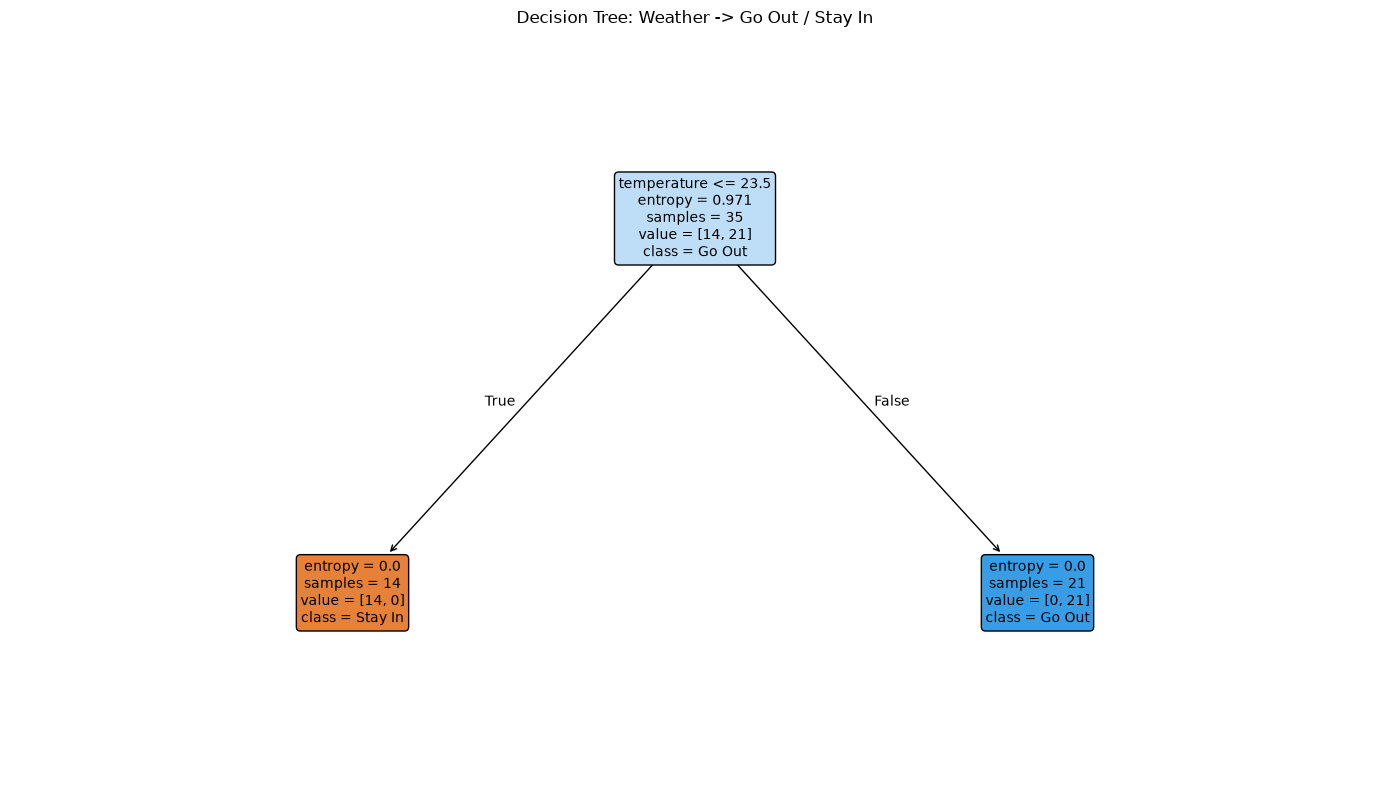

In [6]:
plt.figure(figsize=(14, 8))
plot_tree(model, feature_names=['temperature', 'humidity', 'wind_encoded'],
          class_names=['Stay In', 'Go Out'], filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree: Weather -> Go Out / Stay In')
plt.tight_layout()
plt.show()

## Classification Results

In [7]:
conf_mat = metrics.confusion_matrix(y, y_pred)
print('Confusion Matrix :\n', conf_mat)
Accuracy_score = metrics.accuracy_score(y, y_pred)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ', int(Accuracy_score * 100), '%')

Confusion Matrix :
 [[14  0]
 [ 0 21]]
Accuracy Score :  1.0
Accuracy in Percentage :  100 %


## Conclusion

The tree first splits on weather conditions (sunny vs rainy). When it is sunny (higher temperature, lower humidity), the activity is 'go out'. When it is rainy (lower temperature, higher humidity), the activity is 'stay in'. Wind provides additional refinement for borderline cases.